In [14]:
from dotenv import load_dotenv
from langchain_ollama import ChatOllama
import importlib.metadata as metadata
import langchain

print(f"LangChain: {langchain.__version__}")
print(f"LangGraph: {metadata.version('langgraph')}")

load_dotenv()

llm = ChatOllama(model="gpt-oss:120b-cloud", temperature=0)

print("LLM ready.")

LangChain: 1.3.0
LangGraph: 1.2.0
LLM ready.


In [15]:
from langchain_core.tools import tool

# Reusing familiar local tools from previous lessons
@tool
def get_weather(city: str) -> str:
    """Returns the current weather for a given city."""
    return f"The weather in {city} is sunny with a high of 28C."

@tool
def get_stock_price(ticker: str) -> str:
    """Returns the current stock price for a given ticker symbol.
    Use 'ZENSAR' for Zensar Technologies, 'GOOGL' for Google."""
    prices = {"ZENSAR": "527.90 INR", "GOOGL": "175.00 USD"}
    return prices.get(ticker.upper(), f"Unknown ticker: {ticker}")

TOOLS = [get_weather, get_stock_price]
print("Tools ready: get_weather, get_stock_price")

Tools ready: get_weather, get_stock_price


In [16]:
@tool
def transfer_funds(fromAccount: str, toAccount: str, amount: float) -> str:
    """Transfers money from fromAccount to toAccount as per given amount value"""
    return f"Transferred {amount} from {fromAccount} to {toAccount}"

ALL_TOOLS = TOOLS + [transfer_funds]
SENSITIVE_TOOLS = {"transfer_funds"}
print(f'All Tools: {ALL_TOOLS}')

All Tools: [StructuredTool(name='get_weather', description='Returns the current weather for a given city.', args_schema=<class 'langchain_core.utils.pydantic.get_weather'>, func=<function get_weather at 0x0000019E0D7319E0>), StructuredTool(name='get_stock_price', description="Returns the current stock price for a given ticker symbol.\n    Use 'ZENSAR' for Zensar Technologies, 'GOOGL' for Google.", args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x0000019E0D730CC0>), StructuredTool(name='transfer_funds', description='Transfers money from fromAccount to toAccount as per given amount value', args_schema=<class 'langchain_core.utils.pydantic.transfer_funds'>, func=<function transfer_funds at 0x0000019E0D730C20>)]


In [17]:
# Example 1 - Building LangGraph with HITL
from typing import Annotated, TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

# STEP 1 - Create State
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

print("AgentState is ready!!")

AgentState is ready!!


In [18]:
# Example 2 - Adding tools to Conditional Edge
from langgraph.prebuilt import ToolNode
from langchain_core.messages import SystemMessage, ToolMessage
from langgraph.types import Command, interrupt

llm_with_tools = llm.bind_tools(ALL_TOOLS)

HITL_SYSTEM_PROMPT = SystemMessage(content=(
    "You have access to get_weather, get_stock_price, and transfer_funds. "
    "When the user asks to transfer funds, immediately call the transfer_funds "
    "tool with the requested amount and account - do not ask the user to confirm "
    "in plain text first. A human reviewer approves or denies the transfer "
    "automatically before it executes, so your job is only to call the tool."
))


In [19]:
# Node 1
def assistant_hitl(state: AgentState) -> dict:
    """Call the given LLM with tools"""
    response = llm_with_tools.invoke([HITL_SYSTEM_PROMPT] + state["messages"])
    return {"messages": [response]}

# Node 2
def route_after_assistant_hitl(state: AgentState) -> str:
    """Route to tools only when the model procuded tool calls"""
    last_message = state["messages"][-1]
    tool_calls = getattr(last_message, "tool_calls", None)
    if not tool_calls:
        return END
    if any(call["name"] in SENSITIVE_TOOLS for call in tool_calls):
        return "human_review"
    return "tools"

print("Both Nodes are ready with conditional tools")

Both Nodes are ready with conditional tools


In [20]:
# Node 3 - Human Review Node
def human_review(state: AgentState) -> Command:
    """Pauses the graph and ask a human to approve the call to sensitive tool"""
    last_message = state["messages"][-1]
    tool_call = last_message.tool_calls[0]

    decision = interrupt({
        "question": "Shall I transfer the funds?",
        "tool": tool_call["name"],
        "args": tool_call["args"]
    })

    if decision == "approve":
        return Command(goto="tools")
    denial = ToolMessage(
        content="User denied the funds transfer request",
        tool_call_id=tool_call["id"]
    )
    return Command(goto="assistant_hitl", update={"messages": [denial]})

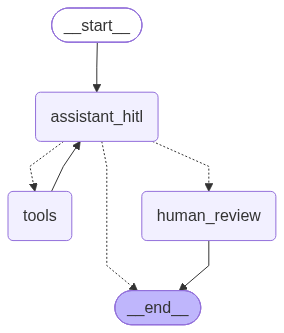

In [21]:
from langgraph.checkpoint.memory import MemorySaver

memory_saver = MemorySaver()

hitl_graph_builder = StateGraph(AgentState)

hitl_graph_builder.add_node("assistant_hitl", assistant_hitl)
hitl_graph_builder.add_node("tools", ToolNode(ALL_TOOLS))
hitl_graph_builder.add_node("human_review", human_review)

hitl_graph_builder.add_edge(START, "assistant_hitl")
hitl_graph_builder.add_conditional_edges(
    "assistant_hitl",
    route_after_assistant_hitl,
    {"tools": "tools", "human_review": "human_review", END: END}
)
hitl_graph_builder.add_edge("tools", "assistant_hitl")
hitl_graph = hitl_graph_builder.compile(checkpointer=memory_saver)
hitl_graph

In [22]:
config_hitl = {"configurable": {"thread_id": "South_indian_dishes_receipes_anand"}}
pending = hitl_graph.invoke(
    {"messages": [{"role": "user", "content": "Which is the capital city of India?"}]},
    config=config_hitl
)

if "__interrupt__" in pending:
    print("Graph is paused.. Interrupt payload: ")
    print(pending["__interrupt__"])
else:
    last_message = pending["messages"][-1]
    print(f'No interrupt called: {last_message}')

No interrupt called: content='The capital city of India is **New\u202fDelhi**.' additional_kwargs={} response_metadata={'model': 'gpt-oss:120b', 'created_at': '2026-07-30T04:54:25.148058705Z', 'done': True, 'done_reason': 'stop', 'total_duration': 880840123, 'load_duration': None, 'prompt_eval_count': 300, 'prompt_eval_duration': None, 'eval_count': 46, 'eval_duration': None, 'logprobs': None, 'model_name': 'gpt-oss:120b', 'model_provider': 'ollama'} id='lc_run--019fb15f-9ca7-7c42-b3bd-984c27aa8d2c-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 300, 'output_tokens': 46, 'total_tokens': 346}


In [23]:
config_hitl = {"configurable": {"thread_id": "South_indian_dishes_receipes_anand"}}
pending = hitl_graph.invoke(
    {"messages": [{"role": "user", "content": "How is the weather in Pune today?"}]},
    config=config_hitl
)

if "__interrupt__" in pending:
    print("Graph is paused.. Interrupt payload: ")
    print(pending["__interrupt__"])
else:
    last_message = pending["messages"][-1]
    print(f'No interrupt called: {last_message}')

No interrupt called: content='Pune is experiencing sunny weather today, with a high around 28\u202f°C.' additional_kwargs={} response_metadata={'model': 'gpt-oss:120b', 'created_at': '2026-07-30T04:54:29.420791572Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2513687145, 'load_duration': None, 'prompt_eval_count': 373, 'prompt_eval_duration': None, 'eval_count': 75, 'eval_duration': None, 'logprobs': None, 'model_name': 'gpt-oss:120b', 'model_provider': 'ollama'} id='lc_run--019fb15f-a753-7a33-a8ae-63334eb369bc-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 373, 'output_tokens': 75, 'total_tokens': 448}


In [24]:
config_hitl = {"configurable": {"thread_id": "South_indian_dishes_receipes_anand"}}
pending = hitl_graph.invoke(
    {"messages": [{"role": "user", "content": "Please transfer 2000 USD from account ACC-1000 to account ACC-2000"}]},
    config=config_hitl
)

if "__interrupt__" in pending:
    print("Graph is paused.. Interrupt payload: ")
    print(pending["__interrupt__"])
else:
    last_message = pending["messages"][-1]
    print(f'No interrupt called: {last_message}')

Graph is paused.. Interrupt payload: 
[Interrupt(value={'question': 'Shall I transfer the funds?', 'tool': 'transfer_funds', 'args': {'amount': 2000, 'fromAccount': 'ACC-1000', 'toAccount': 'ACC-2000'}}, id='5eb4fe570f3516fa6b2404bbc866b15a')]


In [25]:
command = Command(resume="deny")
response = hitl_graph.invoke(command, config=config_hitl)

print(response)

{'messages': [HumanMessage(content='Which is the capital city of India?', additional_kwargs={}, response_metadata={}, id='2fe49e32-4e75-4706-8a38-9361cf41226d'), AIMessage(content='The capital city of India is **New\u202fDelhi**.', additional_kwargs={}, response_metadata={'model': 'gpt-oss:120b', 'created_at': '2026-07-30T04:54:25.148058705Z', 'done': True, 'done_reason': 'stop', 'total_duration': 880840123, 'load_duration': None, 'prompt_eval_count': 300, 'prompt_eval_duration': None, 'eval_count': 46, 'eval_duration': None, 'logprobs': None, 'model_name': 'gpt-oss:120b', 'model_provider': 'ollama'}, id='lc_run--019fb15f-9ca7-7c42-b3bd-984c27aa8d2c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 300, 'output_tokens': 46, 'total_tokens': 346}), HumanMessage(content='How is the weather in Pune today?', additional_kwargs={}, response_metadata={}, id='7a0e2f75-e06f-438e-bab9-8a55811153a3'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': '